Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.170078


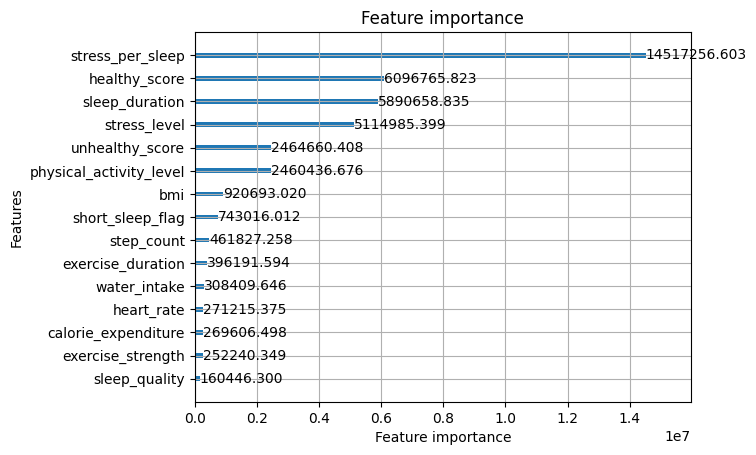


学習用Balanced Accuracy: 0.95002




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

def df_Data_Cleansing(df):
    cat_cols = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().astype('category')

    df['short_sleep_flag'] = (df['sleep_duration'] < 6.0).astype(int)
    df["exercise_strength"] = df['calorie_expenditure'] / ((df['exercise_duration'] + 0.1) * df['bmi'])

    df['healthy_score'] = (
        df['sleep_duration'].between(7, 8).astype(int) +
        (df['bmi'] <= 19).astype(int) +
        (df['exercise_duration'] >= 40).astype(int) +
        (df['stress_level'] == 'low').astype(int) +
        (df['sleep_quality'] == 'good').astype(int) +
        (df['physical_activity_level'] == 'active').astype(int)
    )

    df['unhealthy_score'] = (
        df['sleep_duration'].between(5, 6).astype(int) +
        (df['bmi'] >= 27).astype(int) +
        (df['calorie_expenditure'] <= 1400).astype(int) +
        (df['step_count'] <= 5000).astype(int) +
        (df['exercise_duration'] <= 30).astype(int) +
        (df['stress_level'] == 'high').astype(int) +
        (df['sleep_quality'] == 'poor').astype(int) +
        df['physical_activity_level'].isin(['sedentary', 'moderate']).astype(int) +
        (df['smoking_alcohol'] == 'yes').astype(int)
    )

    stress_mapping = {'low': 1, 'medium': 2, 'high': 3}
    df['stress_level_num'] = df['stress_level'].map(stress_mapping).astype(float)
    df['stress_per_sleep'] = df['stress_level_num'] / df['sleep_duration']

    drop_cols = [
        'stress_level_num',
        'diet_type',
        'gender',
        'smoking_alcohol',
    ]
    df = df.drop(columns=drop_cols, errors='ignore')

    return df

# 1. データの読み込み
df = df_Data_Cleansing(pd.read_csv('data/train.csv',encoding="utf-8"))
df_test = df_Data_Cleansing(pd.read_csv('data/test.csv',encoding="utf-8"))

# 2. 特徴量(X)とターゲット(y)の分割
X = df.drop(['id', 'health_condition'], axis=1)
y = df['health_condition']

# 3. 前処理（エンコーディングと欠損値補完）
le_stress = LabelEncoder()
X['stress_level'] = le_stress.fit_transform(X['stress_level'])
df_test['stress_level'] = le_stress.transform(df_test['stress_level'])

NUMS = X.select_dtypes(include="float").columns.tolist() + X.select_dtypes(include="int").columns.tolist()
train_medians = X[NUMS].median()
X[NUMS] = X[NUMS].fillna(train_medians)
df_test[NUMS] = df_test[NUMS].fillna(train_medians)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. 学習データの8:2分割と評価モデルの学習
X_train, X_valid, y_train, y_valid = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

model_eval = lgb.LGBMClassifier(
    verbose=-1,
    class_weight='balanced',
    random_state=42,
    n_estimators=1000,
    learning_rate=0.013578512419982092,
    num_leaves=92,
    max_depth=9,
    min_child_samples=36,
    subsample=0.505217415288255,
    colsample_bytree=0.7581737202993579
)
model_eval.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

best_iter = model_eval.best_iteration_


lgb.plot_importance(model_eval, max_num_features=20, importance_type='gain')
plt.show()

valid_preds = model_eval.predict(X_valid)
score = balanced_accuracy_score(y_valid, valid_preds)

print(f"""=========================

学習用Balanced Accuracy: {score:.5f}

""")

# 5. 全データでの本番モデル学習と提出ファイルの作成
model_full = lgb.LGBMClassifier(
    verbose=-1,
    class_weight='balanced',
    random_state=42,
    n_estimators=1000,
    learning_rate=0.013578512419982092,
    num_leaves=92,
    max_depth=9,
    min_child_samples=36,
    subsample=0.505217415288255,
    colsample_bytree=0.7581737202993579
)

model_full.set_params(n_estimators=best_iter)
model_full.fit(X, y_encoded)

X_test = df_test.drop(['id'], axis=1)
preds = model_full.predict(X_test)

submission_labels = le.inverse_transform(preds)

submission = pd.DataFrame({
    'id': df_test['id'],
    'health_condition': submission_labels
})
submission.to_csv('submission.csv', index=False)
X_test.head(100).to_csv("submit_x_x_x_x_x_x.csv", index=False)

print("""=========================

提出用ファイル 'submission.csv' を作成しました☆

""")